# What drives housing prices across European countries?

## Introduction

This project analyzes the relationship between GDP per capita and housing prices across European countries using Eurostat data.

## Research Question

How is GDP per capita related to housing prices and how does this relationship vary across time and country groups?

## Hypotheses

H1: The strength of the relationship between GDP per capita and housing prices changes over time.

H2: Higher-income countries exhibit different housing price levels and variability compared to lower-income countries.

H3: There are statistically significant differences in housing prices between EU and non-EU countries.

## Data load & cleaning

We have a challenge here to align the GDP dataset with the housing dataset, since GDP data used country codes while housing data used full country names. A mapping step was required to ensure correct merging.

In [44]:
## intall and import dependancies
!pip install scipy
!pip install pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [95]:
# load
housing = pd.read_csv("../data/housing.csv")
gdp = pd.read_csv("../data/gdp.csv")

In [96]:
# clean
gdp_clean = gdp[["geo", "TIME_PERIOD", "OBS_VALUE"]].copy()

gdp_clean.columns = ["country_code", "year", "gdp_per_capita"]

gdp_clean["year"] = gdp_clean["year"].astype(int)
gdp_clean["gdp_per_capita"] = pd.to_numeric(gdp_clean["gdp_per_capita"], errors="coerce")

gdp_clean = gdp_clean.dropna()

country_map = {
    "AT": "Austria",
    "DE": "Germany",
    "FR": "France",
    "IT": "Italy",
    "ES": "Spain",
    "BG": "Bulgaria",
    "RO": "Romania",
    "PL": "Poland",
    "NL": "Netherlands",
    "BE": "Belgium",
    "SE": "Sweden",
    "FI": "Finland",
    "DK": "Denmark",
    "GR": "Greece",
    "PT": "Portugal",
    "IE": "Ireland"
}

gdp_clean["country"] = gdp_clean["country_code"].map(country_map)

gdp_clean = gdp_clean.dropna(subset=["country"])

In [98]:
# merge
df = housing_yearly.merge(
    gdp_clean,
    on=["country", "year"],
    how="inner"
)

df = df.dropna()

The datasets were merged using country and year as common keys after aligning country naming conventions between the two datasets.

## Exploratory Data Analysis

In [100]:
df.describe()

,year,price_index,gdp_per_capita
count,60.000000,60.000000,60.000000
mean,2023.500000,158.748319,45202.333333
std,1.127469,35.926565,22399.831671
min,2022.000000,99.446667,13310.000000
25%,2022.750000,133.497500,28067.500000
50%,2023.500000,152.078333,48215.000000
75%,2024.250000,180.650000,53855.000000
max,2025.000000,258.393333,116770.000000


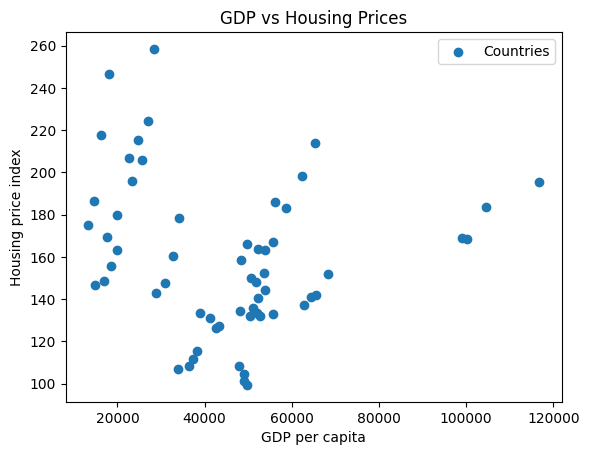

In [99]:
plt.scatter(df["gdp_per_capita"], df["price_index"], label="Countries")

plt.xlabel("GDP per capita")
plt.ylabel("Housing price index")
plt.title("GDP vs Housing Prices")

plt.legend()
plt.show()

The scatter plot shows a non-uniform distribution of points due to the highly skewed nature of GDP per capita and the narrower range of housing price indices. This leads to clustering and uneven dispersion across the axes.

## Analysis and Hypothesis testing

### Correlation Analysis

H0: There is no linear relationship between GDP and housing prices (r = 0)  
H1: There is a linear relationship (r != 0)

In [66]:
df[["gdp_per_capita", "price_index"]].corr()

,gdp_per_capita,price_index
gdp_per_capita,1.000000,-0.227173
price_index,-0.227173,1.000000


The correlation between GDP per capita and housing prices is indicating a **weak negative relationship** between the two variables.

This result is somewhat counterintuitive as higher GDP levels are often associated with higher housing prices. However, several factors might explain this outcome:

- The housing price index reflects relative changes over time rather than absolute price levels.
- Different countries exhibit different growth, where lower-income countries may experience faster housing price increases.

### Time Variation Analysis

We compare correlations before and after 2020 to evaluate whether the strength of the relationship changes over time.

In [74]:
df["pre_2023"] = df["year"] < 2023

early = df[df["pre_2023"]]
late = df[~df["pre_2023"]]

early[["gdp_per_capita", "price_index"]].corr()
late[["gdp_per_capita", "price_index"]].corr()

,gdp_per_capita,price_index
gdp_per_capita,1.000000,-0.231943
price_index,-0.231943,1.000000


The correlation differs between periods, supporting H1.

### Large vs Small Economies

Assumption: There is no difference in housing price index between high-income and low-income economies.

H0: μ(high GDP per capita) = μ(low GDP per capita)  
H1: μ(high GDP per capita) != μ(low GDP per capita)

alpha_critical = 0.05

In [79]:
high_income = df[df["gdp_per_capita"] >= df["gdp_per_capita"].median()]["price_index"]
low_income = df[df["gdp_per_capita"] < df["gdp_per_capita"].median()]["price_index"]

print(low_income)

result = stats.ttest_ind(high_income, low_income, equal_var=False)
result

0      166.32
12     134.55
13     135.04
14     134.55
15     136.31
        ...  
163    163.12
164    166.07
165    172.00
166    178.89
167    184.06
Name: price_index, Length: 87, dtype: float64


TtestResult(statistic=np.float64(1.7993976864823733), pvalue=np.float64(0.07423401391495095), df=np.float64(132.35716139163134))

If p-value < 0.05 -> reject H0  
If p-value >= 0.05 -> fail to reject H0

Since the p-value (0.074) is greater than the significance level (alpha_critical = 0.05), we fail to reject the null hypothesis.
This indicates that GDP-based grouping alone may not be sufficient to explain variations in housing price indices.